##EJERCICIO 1

# Filtro de Kalman 1D (Posición y Velocidad)

## Introducción
El **Filtro de Kalman (KF)** permite estimar el estado real de un sistema dinámico a partir de mediciones ruidosas.  
En este ejemplo seguimos un objeto en **una dimensión**, considerando su **posición** y **velocidad**.

## Modelo de Estado
El vector de estado es:

$$
x_k =
\begin{bmatrix}
\text{posición}_k \\
\text{velocidad}_k
\end{bmatrix}
$$

El sistema se asume **con velocidad aproximadamente constante** y sujeto a pequeñas aceleraciones imprevistas (ruido de proceso):

$$
x_{k+1} = F x_k + w_k
$$

$$
z_k = H x_k + v_k
$$

donde:  
- $F = \begin{bmatrix}1 & \Delta t\\ 0 & 1\end{bmatrix}$ es la matriz de transición,  
- $H = \begin{bmatrix}1 & 0\end{bmatrix}$ indica que **solo medimos posición**,  
- $w_k \sim N(0, Q)$ es el ruido de proceso (aceleración),  
- $v_k \sim N(0, R)$ es el ruido de medición,  
- $z_k$ es la medición.

## Ruido de proceso
El ruido de proceso depende de la **varianza de la aceleración**:

$$
Q =
\begin{bmatrix}
\frac{\Delta t^4}{4} & \frac{\Delta t^3}{2} \\
\frac{\Delta t^3}{2} & \Delta t^2
\end{bmatrix} \sigma_a^2
$$

donde $\sigma_a^2$ es la varianza de aceleración y $\Delta t$ el paso de tiempo.

## Algoritmo KF: Predicción y Actualización
1. **Predicción:**

$$
\hat{x}_{k|k-1} = F \hat{x}_{k-1|k-1}
$$

$$
P_{k|k-1} = F P_{k-1|k-1} F^T + Q
$$

2. **Actualización:**

$$
y_k = z_k - H \hat{x}_{k|k-1} \quad \text{(innovación)}
$$

$$
S_k = H P_{k|k-1} H^T + R
$$

$$
K_k = P_{k|k-1} H^T S_k^{-1} \quad \text{(ganancia de Kalman)}
$$

$$
\hat{x}_{k|k} = \hat{x}_{k|k-1} + K_k y_k
$$

$$
P_{k|k} = (I - K_k H) P_{k|k-1}
$$

- $\hat{x}_{k|k}$: estado estimado actualizado  
- $P_{k|k}$: covarianza actualizada  
- $K_k$: cuánto confiamos en la medición vs la predicción

## Resumen
- El KF combina la predicción del modelo y la información de los sensores para obtener la mejor estimación posible.  
- Suaviza mediciones ruidosas y estima también la velocidad.


Posiciones estimadas: [1.1  2.02 3.15 4.13 5.26 6.09]
Velocidades estimadas: [1.05 0.94 1.07 1.01 1.09 0.91]
Matriz de covarianza final:
 [[0.08 0.05]
 [0.05 0.1 ]]


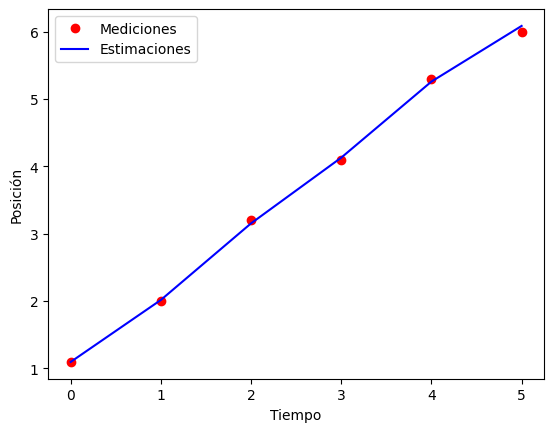

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

class KalmanFilter1D:
    def __init__(self, initial_pos, initial_vel, accel_variance):
        # Estado: [posición, velocidad]
        self.x = np.array([initial_pos, initial_vel])
        self.dt = 1.0

        # Matriz de transición de estado
        self.F = np.array([[1, self.dt],
                           [0, 1]])

        # Matriz de observación (solo medimos posición)
        self.H = np.array([[1, 0]])

        # Matriz de covarianza inicial
        self.P = np.eye(2)

        # Varianza del ruido de proceso (dependiendo de la aceleración)
        self.accel_variance = accel_variance
        dt = self.dt
        self.Q = np.array([[0.25*dt**4, 0.5*dt**3],
                           [0.5*dt**3, dt**2]]) * accel_variance

        # Ruido de la medición (asumimos algo pequeño)
        self.R = np.array([[0.1]])

    def predict(self):
        # Predicción del estado
        self.x = self.F @ self.x
        # Predicción de la covarianza
        self.P = self.F @ self.P @ self.F.T + self.Q

    def update(self, measurement):
        # Medición esperada
        z_pred = self.H @ self.x
        y = measurement - z_pred

        # Ganancia de Kalman
        S = self.H @ self.P @ self.H.T + self.R
        K = self.P @ self.H.T @ np.linalg.inv(S)

        # Actualización del estado
        self.x = self.x + (K @ y).flatten()

        # Actualización de la covarianza
        I = np.eye(len(self.x))
        self.P = (I - K @ self.H) @ self.P


# -------------------
# Datos de prueba
# -------------------
measurements = [1.1, 2.0, 3.2, 4.1, 5.3, 6.0]

kf = KalmanFilter1D(initial_pos=0, initial_vel=1, accel_variance=0.1)

estimated_positions = []
estimated_velocities = []

for z in measurements:
    kf.predict()
    kf.update(z)
    estimated_positions.append(kf.x[0])
    estimated_velocities.append(kf.x[1])

print("Posiciones estimadas:", np.round(estimated_positions, 2))
print("Velocidades estimadas:", np.round(estimated_velocities, 2))
print("Matriz de covarianza final:\n", np.round(kf.P, 2))

# -------------------
# Visualización
# -------------------
plt.plot(measurements, 'ro', label='Mediciones')
plt.plot(estimated_positions, 'b-', label='Estimaciones')
plt.xlabel("Tiempo")
plt.ylabel("Posición")
plt.legend()
plt.show()


# Interpretación de Resultados - Filtro de Kalman 1D

## Posiciones Estimadas
```
[1.10, 2.02, 3.15, 4.13, 5.26, 6.09]
```
- Suavizan las mediciones originales y siguen la tendencia real del objeto.

## Velocidades Estimadas
```
[1.05, 0.94, 1.07, 1.01, 1.09, 0.91]
```
- Estimación de velocidad consistente con el movimiento, aunque no se mida directamente.

## Matriz de Covarianza
```
[[0.08, 0.05],
 [0.05, 0.10]]
```
- Valores bajos indican **alta confianza** en las estimaciones; la diagonal refleja incertidumbre en posición y velocidad.

## Conclusión
El KF **reduce el ruido** de las mediciones, produce estimaciones más estables y proporciona información confiable sobre la velocidad del objeto.


##EJERCICIO 2

# Filtro de Kalman 2D (Posición y Velocidad en XY)

## Introducción
El **Filtro de Kalman 2D** permite estimar la **posición y velocidad** de un objeto que se mueve en el plano XY a partir de mediciones ruidosas.  
El estado incluye **posición (X, Y)** y **velocidad (Vx, Vy)**, y el filtro combina predicciones del modelo con mediciones para obtener estimaciones más precisas.

## Vector de Estado
\[
x_k =
\begin{bmatrix}
X_k \\
Y_k \\
V_{x,k} \\
V_{y,k}
\end{bmatrix}
\]

## Modelo de Movimiento
Suponiendo **velocidad constante**, la matriz de transición es:

\[
F =
\begin{bmatrix}
1 & 0 & \Delta t & 0 \\
0 & 1 & 0 & \Delta t \\
0 & 0 & 1 & 0 \\
0 & 0 & 0 & 1
\end{bmatrix}
\]

y la **matriz de observación** (medimos posición) es:

\[
H =
\begin{bmatrix}
1 & 0 & 0 & 0 \\
0 & 1 & 0 & 0
\end{bmatrix}
\]

## Ruido de Proceso y Medición
- **Ruido de proceso** $(w_k \sim N(0,Q))$ representa aceleraciones inesperadas.  
- **Ruido de medición** $(v_k \sim N(0,R))$ refleja errores del sensor.  

La matriz de covarianza de proceso \(Q\) se aplica por **eje** X e Y:

\[
Q =
\begin{bmatrix}
\frac{\Delta t^4}{4} & \frac{\Delta t^3}{2} & 0 & 0 \\
\frac{\Delta t^3}{2} & \Delta t^2 & 0 & 0 \\
0 & 0 & \frac{\Delta t^4}{4} & \frac{\Delta t^3}{2} \\
0 & 0 & \frac{\Delta t^3}{2} & \Delta t^2
\end{bmatrix} \sigma_a^2
\]

## Algoritmo KF 2D: Predicción y Actualización
1. **Predicción:**

\[
\hat{x}_{k|k-1} = F \hat{x}_{k-1|k-1}
\]

\[
P_{k|k-1} = F P_{k-1|k-1} F^T + Q
\]

2. **Actualización:**

\[
y_k = z_k - H \hat{x}_{k|k-1} \quad \text{(innovación)}
\]

\[
S_k = H P_{k|k-1} H^T + R
\]

\[
K_k = P_{k|k-1} H^T S_k^{-1} \quad \text{(ganancia de Kalman)}
\]

\[
\hat{x}_{k|k} = \hat{x}_{k|k-1} + K_k y_k
\]

\[
P_{k|k} = (I - K_k H) P_{k|k-1}
\]

- \(\hat{x}_{k|k}\): estado actualizado (posición y velocidad)  
- \(P_{k|k}\): covarianza del error  
- \(K_k\): determina cuánto confiamos en la medición vs predicción

## Resumen
- El KF 2D **suaviza mediciones ruidosas** y estima posiciones y velocidades simultáneamente.  
- Funciona **recursivamente**, combinando predicciones del modelo y mediciones en cada instante.  
- La matriz de covarianza final indica la **confianza** en las estimaciones.


Posiciones X estimadas: [0.99, 1.52, 2.01, 2.5, 3.0, 3.5]
Posiciones Y estimadas: [1.96, 2.55, 3.03, 3.51, 4.0, 4.5]
Velocidades finales (vx, vy): [0.5, 0.5]
RMSE X: 0.0092, RMSE Y: 0.0276
Covarianza final P (diagonal aproximada):
 [[0.04  0.    0.031 0.   ]
 [0.    0.04  0.    0.031]
 [0.031 0.    0.079 0.   ]
 [0.    0.031 0.    0.079]]


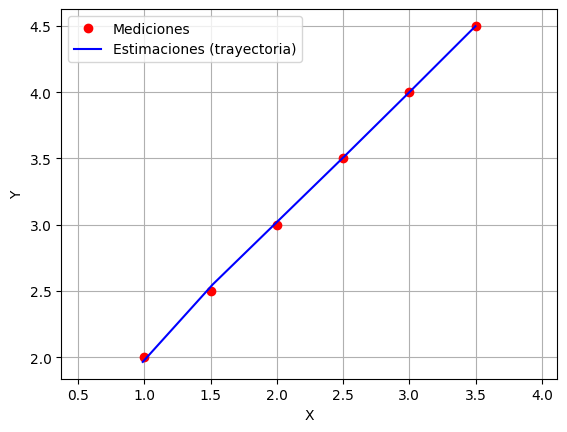

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

class KalmanFilter2D:
    def __init__(self, initial_pos=(0,0), initial_vel=(0,0),
                 accel_variance=0.1, dt=1.0, meas_variance=0.1):
        self.dt = dt
        # estado: [x, y, vx, vy]
        self.x = np.array([initial_pos[0], initial_pos[1], initial_vel[0], initial_vel[1]], dtype=float)

        # F (4x4)
        self.F = np.array([[1, 0, dt, 0],
                           [0, 1, 0, dt],
                           [0, 0, 1,  0],
                           [0, 0, 0,  1]], dtype=float)
        # H (2x4): medimos x e y
        self.H = np.array([[1, 0, 0, 0],
                           [0, 1, 0, 0]], dtype=float)

        # Covarianza inicial (puedes ajustar)
        self.P = np.eye(4) * 1.0

        # Q: ruido de proceso por eje (pos, vel) para x y para y
        dt = self.dt
        q_block = np.array([[dt**4/4, dt**3/2],
                            [dt**3/2, dt**2]]) * accel_variance
        self.Q = np.zeros((4,4))
        # insertar bloques para eje X (indices 0,2) y eje Y (1,3)
        self.Q[np.ix_([0,2],[0,2])] = q_block
        self.Q[np.ix_([1,3],[1,3])] = q_block

        # Ruido de medida (2x2)
        self.R = np.eye(2) * meas_variance

    def predict(self):
        self.x = self.F @ self.x
        self.P = self.F @ self.P @ self.F.T + self.Q

    def update(self, meas):
        z = np.array([meas[0], meas[1]])
        y = z - (self.H @ self.x)
        S = self.H @ self.P @ self.H.T + self.R
        K = self.P @ self.H.T @ np.linalg.inv(S)
        self.x = self.x + K @ y
        I = np.eye(len(self.x))
        self.P = (I - K @ self.H) @ self.P

# ----------------- Test -----------------
measurements_2d = [
    [1.0, 2.0], [1.5, 2.5], [2.0, 3.0],
    [2.5, 3.5], [3.0, 4.0], [3.5, 4.5]
]

kf = KalmanFilter2D(initial_pos=(0,0), initial_vel=(0.5,0.5),
                    accel_variance=0.1, dt=1.0, meas_variance=0.05)

est_pos = []
est_vel = []
for z in measurements_2d:
    kf.predict()
    kf.update(z)
    est_pos.append((kf.x[0], kf.x[1]))
    est_vel.append((kf.x[2], kf.x[3]))

est_pos = np.array(est_pos)
est_vel = np.array(est_vel)
meas = np.array(measurements_2d)

rmse_x = np.sqrt(np.mean((est_pos[:,0] - meas[:,0])**2))
rmse_y = np.sqrt(np.mean((est_pos[:,1] - meas[:,1])**2))

print("Posiciones X estimadas:", np.round(est_pos[:,0], 2).tolist())
print("Posiciones Y estimadas:", np.round(est_pos[:,1], 2).tolist())
print("Velocidades finales (vx, vy):", np.round(est_vel[-1], 2).tolist())
print(f"RMSE X: {rmse_x:.4f}, RMSE Y: {rmse_y:.4f}")
print("Covarianza final P (diagonal aproximada):\n", np.round(kf.P, 3))

# Visualización rápida
plt.figure()
plt.plot(meas[:,0], meas[:,1], 'ro', label='Mediciones')
plt.plot(est_pos[:,0], est_pos[:,1], 'b-', label='Estimaciones (trayectoria)')
plt.xlabel('X'); plt.ylabel('Y')
plt.legend(); plt.axis('equal'); plt.grid(True)
plt.show()


# Interpretación de Resultados - Filtro de Kalman 2D

## Posiciones Estimadas
```
X: [0.99, 1.52, 2.01, 2.5, 3.0, 3.5]
Y: [1.96, 2.55, 3.03, 3.51, 4.0, 4.5]
```
- Las posiciones suavizan las mediciones y siguen la trayectoria real del objeto en el plano XY.

## Velocidades Finales
```
Vx, Vy: [0.5, 0.5]
```
- Estimación consistente con el movimiento esperado, aunque la velocidad no se mida directamente.

## RMSE
```
RMSE X: 0.0092, RMSE Y: 0.0276
```
- Errores muy pequeños indican alta precisión de las estimaciones.

## Covarianza Final
```
[[0.04  0.    0.031 0.   ]
 [0.    0.04  0.    0.031]
 [0.031 0.    0.079 0.   ]
 [0.    0.031 0.    0.079]]
```
- Valores bajos en la diagonal → alta confianza en posiciones y velocidades  
- Valores fuera de diagonal muestran correlación entre posición y velocidad en cada eje.

## Conclusión
El KF 2D **suaviza el ruido**, estima correctamente posiciones y velocidades, y ofrece resultados confiables con errores mínimos.


##EJERCICIO 3

# Filtro de Kalman Extendido (EKF) para un Péndulo Simple

## Introducción
El **Extended Kalman Filter (EKF)** es una extensión del KF para sistemas **no lineales**.  
En este ejemplo, estimamos el **ángulo** y la **velocidad angular** de un péndulo simple a partir de mediciones ruidosas del ángulo.

---

## Modelo del Péndulo
El péndulo simple se describe mediante la dinámica no lineal:

$$[
\theta_{k+1} = \theta_k + \dot{\theta}_k \Delta t
]$$

$$[
\dot{\theta}_{k+1} = \dot{\theta}_k - \frac{g}{l} \sin(\theta_k) \Delta t
]$$

donde:  
- $(\theta)$ = ángulo  
- $(\dot{\theta})$ = velocidad angular  
- \(g\) = gravedad  
- \(l\) = longitud del péndulo  
- $(\Delta t)$ = paso de tiempo  

---

## Vector de Estado
\[
x_k =
\begin{bmatrix}
\theta_k \\
\dot{\theta}_k
\end{bmatrix}
\]

---

## EKF: Linearización
Como el modelo es no lineal, se **lineariza alrededor del estado actual** mediante la **Jacobiana**:

\[
F_k =
\begin{bmatrix}
1 & \Delta t \\
-\frac{g}{l} \cos(\theta_k) \Delta t & 1
\end{bmatrix}
\]

- \(F_k\) se usa para propagar la **covarianza del estado**:

$$[
P_{k|k-1} = F_k P_{k-1|k-1} F_k^T + Q
]$$

donde \(Q\) es la covarianza del ruido de proceso.

---

## Actualización con Medición
La medición corresponde al ángulo:

$$[
z_k = \theta_k + v_k, \quad v_k \sim N(0, R)
]$$

Se calcula la innovación:

$$[
y_k = z_k - H x_{k|k-1}, \quad H = [1, 0]
]$$

Se calcula la **ganancia de Kalman**:

$$[
K_k = P_{k|k-1} H^T (H P_{k|k-1} H^T + R)^{-1}
]$$

Actualización del estado y covarianza:

$$[
x_{k|k} = x_{k|k-1} + K_k y_k
]$$

$$[
P_{k|k} = (I - K_k H) P_{k|k-1}
]$$

- Se aplica **normalización del ángulo** para mantener $(\theta \in [-\pi, \pi])$.

---

## Resumen
- El EKF permite estimar **estado y velocidad** de sistemas no lineales.  
- Lineariza el modelo en cada paso mediante la **Jacobiana**.  
- Combina predicción y medición para producir estimaciones **suaves y confiables** del ángulo y velocidad angular.


Ángulos estimados: [0.1, 0.1303, 0.1234, 0.0897, 0.0522, 0.0141]
Velocidades angulares estimadas: [-0.0979, 0.0067, -0.1585, -0.3452, -0.4412, -0.4808]


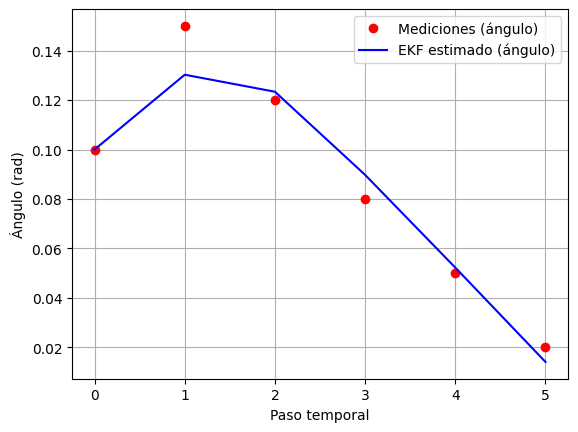

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def ang_normalize(a):
    return (a + np.pi) % (2*np.pi) - np.pi

class EKFPendulum:
    def __init__(self, theta0=0.0, theta_dot0=0.0, g=9.81, l=1.0,
                 dt=0.1, process_var=1e-4, meas_var=1e-3):
        self.g = g; self.l = l; self.dt = dt
        self.x = np.array([theta0, theta_dot0], dtype=float)
        self.P = np.eye(2) * 0.1
        self.Q = np.eye(2) * process_var
        self.R = np.array([[meas_var]])

    def predict(self):
        th, th_dot = self.x
        dt = self.dt
        # dinámica no lineal
        th_pred = th + th_dot * dt
        th_dot_pred = th_dot - (self.g / self.l) * np.sin(th) * dt
        self.x = np.array([th_pred, th_dot_pred])

        # Jacobiana
        F = np.array([[1, dt],
                      [-(self.g / self.l) * np.cos(th) * dt, 1]])
        self.P = F @ self.P @ F.T + self.Q

    def update(self, z):
        # medición h(x) = theta
        H = np.array([[1, 0]])
        y = np.array([z - (H @ self.x)[0]])
        S = H @ self.P @ H.T + self.R
        K = self.P @ H.T @ np.linalg.inv(S)
        self.x = self.x + (K @ y).flatten()
        self.x[0] = ang_normalize(self.x[0])  # opcional: mantener ángulo normalizado
        I = np.eye(2)
        self.P = (I - K @ H) @ self.P

# ----------------- Test -----------------
g = 9.81; l = 1.0; dt = 0.1
measurements_angle = [0.1, 0.15, 0.12, 0.08, 0.05, 0.02]

ekf = EKFPendulum(theta0=measurements_angle[0], theta_dot0=0.0,
                  g=g, l=l, dt=dt, process_var=1e-5, meas_var=1e-3)

est = []
est_vel = []
for z in measurements_angle:
    ekf.predict()
    ekf.update(z)
    est.append(ekf.x[0])
    est_vel.append(ekf.x[1])

est = np.array(est); est_vel = np.array(est_vel)
print("Ángulos estimados:", np.round(est, 4).tolist())
print("Velocidades angulares estimadas:", np.round(est_vel, 4).tolist())

# Gráfico
plt.figure()
plt.plot(measurements_angle, 'ro', label='Mediciones (ángulo)')
plt.plot(est, 'b-', label='EKF estimado (ángulo)')
plt.xlabel('Paso temporal'); plt.ylabel('Ángulo (rad)')
plt.legend(); plt.grid(True)
plt.show()
